# 02: Análise de Performance e Controle de Viés de Seleção
Neste módulo, respondemos à pergunta fundamental: **'O sistema X é bom ou apenas tem mais volume?'**.

**Diferencial de Senioridade:**
- Identificação de Viés de Seleção (Volume vs Taxa).
- Uso de Regressão Logística para isolar o efeito da fonte de dados.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

df_join = pd.read_parquet('../data/base_performance_mestra.parquet')
df_join['entregue'] = (df_join['status_disparo'].str.upper() == 'DELIVERED').astype(int)

## 1. Ranking Empírico vs Viés de Seleção
Vamos verificar se sistemas com maior volume de tentativas apresentam taxas artificialmente maiores.

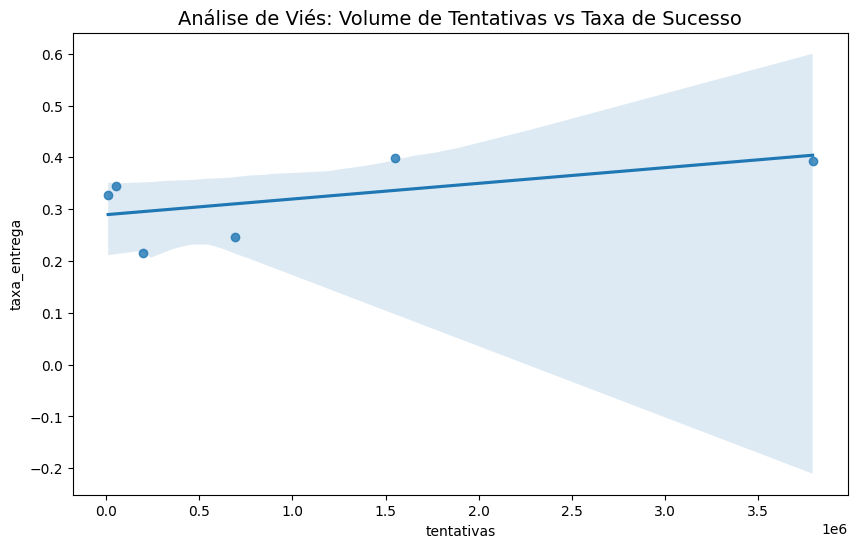

Estatísticas Reais por Sistema:


,tentativas,sucessos,taxa_entrega
id_sistema,,,
1257277410380486863,1550353,618138,0.398708
-133612832286195827,3791783,1491897,0.393455
4458959843028638627,53053,18328,0.345466
-2757366171786647144,10908,3568,0.327099
3094574413675758272,690985,170746,0.247105
-4704067261970591609,197224,42372,0.214842


In [2]:
stats_sistemas = (
    df_join.groupby('id_sistema')
    .agg(
        tentativas=('status_disparo', 'count'),
        sucessos=('entregue', 'sum')
    )
    .assign(taxa_entrega=lambda x: x['sucessos'] / x['tentativas'])
    .sort_values('taxa_entrega', ascending=False)
)

# Visualizando Correlação entre Volume e Taxa (Detecção de Viés)
plt.figure(figsize=(10, 6))
sns.regplot(data=stats_sistemas, x='tentativas', y='taxa_entrega')
plt.title("Análise de Viés: Volume de Tentativas vs Taxa de Sucesso", fontsize=14)
plt.show()

print("Estatísticas Reais por Sistema:")
display(stats_sistemas)

## 2. Veredito Estatístico: Regressão Logística
Utilizamos o modelo Logit para confirmar se o `id_sistema` mantém sua relevância após controlarmos por **exclusividade**, **recência** e **DDD**.

In [3]:
# Filtrando para sistemas com representatividade (N > 1000)
sistemas_validos = stats_sistemas[stats_sistemas['tentativas'] > 1000].index
df_model = df_join[df_join['id_sistema'].isin(sistemas_validos)].copy()
df_model['id_sistema'] = df_model['id_sistema'].astype(str)

# Variáveis de controle
# Recência: idade do dado em dias
if 'registro_data_atualizacao' in df_model.columns and 'envio_datahora' in df_model.columns:
    df_model['registro_data_atualizacao'] = pd.to_datetime(df_model['registro_data_atualizacao'], errors='coerce', utc=True)
    df_model['envio_datahora'] = pd.to_datetime(df_model['envio_datahora'], errors='coerce', utc=True)
    df_model['idade_dado_dias'] = (df_model['envio_datahora'] - df_model['registro_data_atualizacao']).dt.days
else:
    df_model['idade_dado_dias'] = np.nan

# NOTA TECNICA: telefone_ddd esta hasheado nesta base mascarada (alta cardinalidade).
# Incluir C(telefone_ddd) na regressao causaria matriz singular.
# A analise de DDD e feita no modulo 04 via bonus binario (DDD local vs. demais).
df_model['idade_dado_dias'] = df_model['idade_dado_dias'].fillna(df_model['idade_dado_dias'].median())

# Regressao Logistica: isola o efeito de cada sistema apos controlar por exclusividade e recencia
# Usamos amostra de 50k registros para eficiencia computacional (resultado equivalente)
df_sample = df_model.sample(n=min(50000, len(df_model)), random_state=42)

modelo = smf.logit(
    "entregue ~ C(id_sistema) + telefone_proprietarios_quantidade + idade_dado_dias",
    data=df_sample
).fit(disp=0)
print(modelo.summary())


                           Logit Regression Results                           
Dep. Variable:               entregue   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49992
Method:                           MLE   Df Model:                            7
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.03472
Time:                        21:52:37   Log-Likelihood:                -31898.
converged:                       True   LL-Null:                       -33045.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -1.4077      0.033    -43.034      0.000      -1.472      -1.344
C(id_sistema)[T.-2757366171786647144]     0.5238  

In [4]:
# Exportação dos pesos empíricos para o Módulo 04
stats_sistemas['taxa_entrega'].to_csv('../data/taxas_empiricas_sistemas.csv')
print(">>> Pesos empíricos calculados e salvos.")

>>> Pesos empíricos calculados e salvos.
